# Medium Time-Series Dataset Generator

Generates 150 synthetic time series across 6 signal types, then filters out
simple Sine waves to produce a 110-sample dataset.

**Signal types:**

| Category | Name | Description |
|---|---|---|
| Complex | ARMA | Economic/financial random walk |
| Complex | Heteroscedastic | Expanding variance with seasonal component |
| Complex | Logistic | S-curve trend |
| Rhythmic | ECG | Synthetic heartbeat (Gaussian P-QRS-T) |
| Rhythmic | Square | Square wave |
| Rhythmic | Sine | Pure sine wave (**removed in final dataset**) |

Output format: list of dicts with keys `series_id`, `unique_id`, `category`,
`name`, `anomaly_info`, `source_path`, `data` (pd.Series, DatetimeIndex).

## 1. Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal
from collections import Counter

SEED = 42
N_SERIES = 150
N_POINTS = 600

np.random.seed(SEED)

print(f"Seed: {SEED}")
print(f"Series to generate: {N_SERIES}")
print(f"Points per series: {N_POINTS}")

Seed: 42
Series to generate: 150
Points per series: 600


## 2. Base series generators

In [2]:
def base_arma(n):
    """Economic/Financial random walk process."""
    ar, ma = [1.0], [0.0]
    white_noise = np.random.normal(0, 1, n + 100)
    y = np.zeros(n + 100)
    for i in range(1, len(y)):
        ar_term = sum([ar[j] * y[i-(j+1)] for j in range(len(ar)) if i-(j+1) >= 0])
        ma_term = sum([ma[j] * white_noise[i-(j+1)] for j in range(len(ma)) if i-(j+1) >= 0])
        y[i] = ar_term + ma_term + white_noise[i]
    return y[100:] * 2 + 10


def base_heteroscedastic(n, t):
    """Volatile process with expanding variance."""
    trend = 0.02 * t + 5
    seasonal = 3 * np.sin(2 * np.pi * t / 90)
    envelope = 1 + 0.5 * np.sin(2 * np.pi * t / 300)
    noise = np.random.normal(0, 0.5, n) * envelope
    return trend + seasonal + noise


def base_logistic(n, t):
    """S-Curve Trend."""
    L = 15
    k = 0.04
    x0 = 300
    trend = L / (1 + np.exp(-k * (t - x0)))
    noise = np.random.normal(0, 0.3, n)
    return trend + noise


def base_ecg_simulation(n, t, period=60):
    """Synthetic ECG/Heartbeat signal using smooth Gaussians (P-QRS-T complex)."""
    template_len = int(period)
    template = np.zeros(template_len)
    x = np.arange(template_len)

    # P-wave (Atrial Depolarization)
    p_center = int(0.2 * period)
    p_width = period * 0.05
    template += 0.8 * np.exp(-0.5 * ((x - p_center) / p_width)**2)

    # QRS Complex (Ventricular Depolarization)
    qrs_center = int(0.45 * period)

    # R-wave
    r_width = period * 0.015
    template += 6.0 * np.exp(-0.5 * ((x - qrs_center) / r_width)**2)

    # Q-wave
    q_center = qrs_center - int(period * 0.05)
    q_width = period * 0.015
    template -= 1.5 * np.exp(-0.5 * ((x - q_center) / q_width)**2)

    # S-wave
    s_center = qrs_center + int(period * 0.05)
    s_width = period * 0.015
    template -= 1.5 * np.exp(-0.5 * ((x - s_center) / s_width)**2)

    # T-wave (Ventricular Repolarization)
    t_center = int(0.75 * period)
    t_width = period * 0.08
    template += 1.8 * np.exp(-0.5 * ((x - t_center) / t_width)**2)

    num_reps = int(np.ceil(n / period)) + 1
    full_signal = np.tile(template, num_reps)
    return full_signal[:n] + 10


def base_square_wave(n, t, period=60):
    """Standard Square Wave."""
    return 5 * scipy.signal.square(2 * np.pi * t / period) + 15


def base_sine_wave(n, t, period=60):
    """Standard Sine Wave."""
    return 5 * np.sin(2 * np.pi * t / period) + 15

## 3. Generate 150 series

In [3]:
def generate_series(series_id, n_points=N_POINTS):
    """Generate a single time series and return it in the standard pickle format."""
    dates = pd.date_range(start='2024-01-01', periods=n_points, freq='D', name='time')
    t = np.arange(n_points)

    category = np.random.choice(['Complex', 'Rhythmic'], p=[0.4, 0.6])

    if category == 'Complex':
        name = np.random.choice(['ARMA', 'Heteroscedastic', 'Logistic'])
        if name == 'ARMA':
            y = base_arma(n_points)
        elif name == 'Heteroscedastic':
            y = base_heteroscedastic(n_points, t)
        else:
            y = base_logistic(n_points, t)
    else:
        name = np.random.choice(['ECG', 'Square', 'Sine'])
        period = np.random.choice([40, 60, 80])
        if name == 'ECG':
            y = base_ecg_simulation(n_points, t, period)
        elif name == 'Square':
            y = base_square_wave(n_points, t, period)
        else:
            y = base_sine_wave(n_points, t, period)

        # Background noise
        noise_std = 0.1 if name == 'ECG' else 0.2
        y += np.random.normal(0, noise_std, n_points)

    series = pd.Series(data=y, index=dates, name='value', dtype=np.float64)

    return {
        'series_id': series_id,
        'unique_id': f'ts_medium_s{series_id:03d}',
        'category': category,
        'name': name,
        'anomaly_info': 'No anomalies',
        'source_path': 'generated/time_series_medium_dataset_v3',
        'data': series,
    }


np.random.seed(SEED)
full_dataset = [generate_series(i) for i in range(N_SERIES)]

print(f"Generated {len(full_dataset)} series")
print(f"\nName distribution:")
for name, count in sorted(Counter(s['name'] for s in full_dataset).items(), key=lambda x: -x[1]):
    print(f"  {name:20s} : {count}")
print(f"\nCategory distribution:")
for cat, count in sorted(Counter(s['category'] for s in full_dataset).items(), key=lambda x: -x[1]):
    print(f"  {cat:20s} : {count}")

Generated 150 series

Name distribution:
  Sine                 : 40
  Square               : 38
  ECG                  : 28
  ARMA                 : 17
  Logistic             : 15
  Heteroscedastic      : 12

Category distribution:
  Rhythmic             : 106
  Complex              : 44


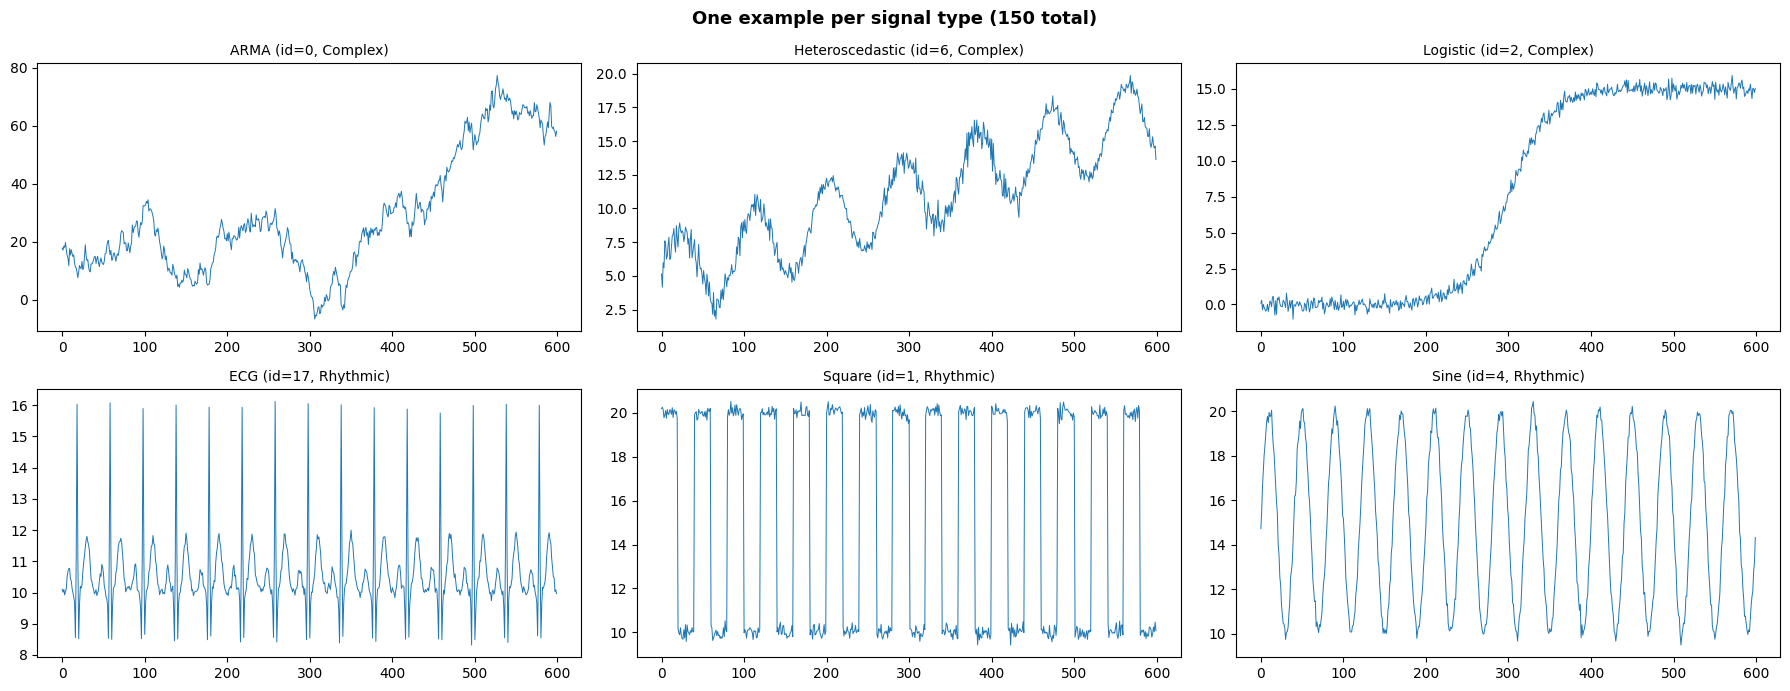

In [4]:
# Spot-check: one sample from each signal type
signal_types = ['ARMA', 'Heteroscedastic', 'Logistic', 'ECG', 'Square', 'Sine']
fig, axes = plt.subplots(2, 3, figsize=(18, 7), squeeze=False)

for idx, sig_name in enumerate(signal_types):
    r, c = divmod(idx, 3)
    sample = next(s for s in full_dataset if s['name'] == sig_name)
    axes[r][c].plot(sample['data'].values, linewidth=0.7)
    axes[r][c].set_title(f"{sig_name} (id={sample['series_id']}, {sample['category']})", fontsize=10)

plt.suptitle('One example per signal type (150 total)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Filter out Sine waves and re-index

In [5]:
sine_indices = [i for i, s in enumerate(full_dataset) if s['name'] == 'Sine']
print(f"Sine samples to remove: {len(sine_indices)}")

filtered_dataset = []
for i, sample in enumerate(full_dataset):
    if sample['name'] == 'Sine':
        continue
    new_sample = dict(sample)
    new_sample['series_id'] = len(filtered_dataset)
    new_sample['unique_id'] = f'ts_medium_s{len(filtered_dataset):03d}'
    filtered_dataset.append(new_sample)

print(f"Filtered dataset size: {len(filtered_dataset)}")
print(f"\nRemaining name distribution:")
for name, count in sorted(Counter(s['name'] for s in filtered_dataset).items(), key=lambda x: -x[1]):
    print(f"  {name:20s} : {count}")

Sine samples to remove: 40
Filtered dataset size: 110

Remaining name distribution:
  Square               : 38
  ECG                  : 28
  ARMA                 : 17
  Logistic             : 15
  Heteroscedastic      : 12


In [6]:
# Sanity checks
ids = [s['series_id'] for s in filtered_dataset]
assert ids == list(range(len(filtered_dataset))), 'series_id not contiguous!'
assert filtered_dataset[0]['data'].index.name == 'time'
assert filtered_dataset[0]['data'].name == 'value'
assert len(filtered_dataset[0]['data']) == N_POINTS
assert all(s['name'] != 'Sine' for s in filtered_dataset)
print(f"All checks passed  ✓")
print(f"series_id: 0 .. {len(filtered_dataset) - 1}")
print(f"Series length: {len(filtered_dataset[0]['data'])}")
print(f"Index: {filtered_dataset[0]['data'].index[:3].tolist()}")

All checks passed  ✓
series_id: 0 .. 109
Series length: 600
Index: [Timestamp('2024-01-01 00:00:00'), Timestamp('2024-01-02 00:00:00'), Timestamp('2024-01-03 00:00:00')]


## 5. Visual check of filtered dataset

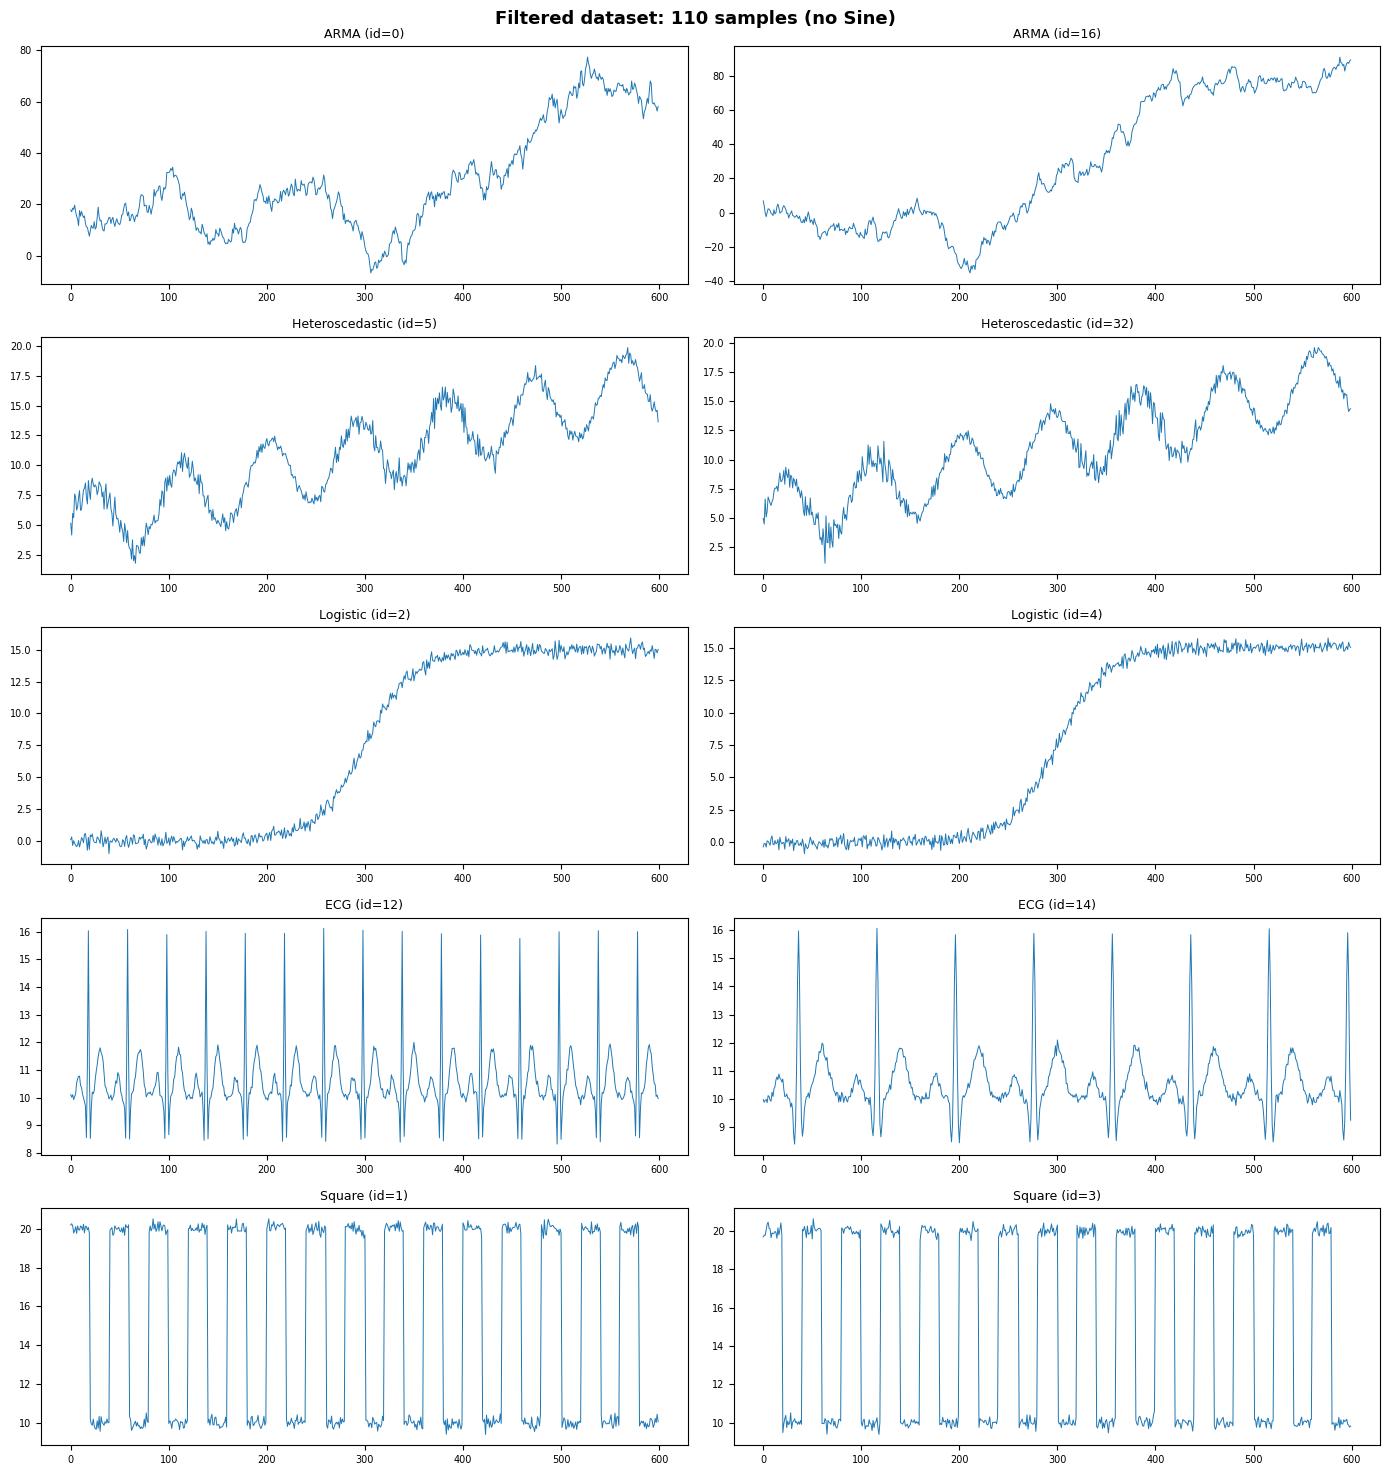

In [7]:
# Show 2 examples from each remaining signal type
remaining_types = ['ARMA', 'Heteroscedastic', 'Logistic', 'ECG', 'Square']
fig, axes = plt.subplots(len(remaining_types), 2, figsize=(14, 3 * len(remaining_types)), squeeze=False)

for row, sig_name in enumerate(remaining_types):
    samples = [s for s in filtered_dataset if s['name'] == sig_name]
    for col in range(min(2, len(samples))):
        axes[row][col].plot(samples[col]['data'].values, linewidth=0.7)
        axes[row][col].set_title(
            f"{sig_name} (id={samples[col]['series_id']})", fontsize=9)
        axes[row][col].tick_params(labelsize=7)

plt.suptitle(f'Filtered dataset: {len(filtered_dataset)} samples (no Sine)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Save (disabled — uncomment to write)

Output: `dataset_ts_medium_<size>.pkl`

In [ ]:
import pickle
from pathlib import Path

output_path = Path(f'dataset_ts_medium_{len(filtered_dataset)}.pkl')
with open(output_path, 'wb') as f:
    pickle.dump(filtered_dataset, f)
print(f'Saved {len(filtered_dataset)} samples to {output_path}')
print(f'File size: {output_path.stat().st_size / 1024:.1f} KB')

print(f'Dataset ready: {len(filtered_dataset)} samples')
print('Uncomment the block above to save as pickle.')